In [ ]:
!pip install numpy tensorflow sklearn seaborn

import numpy as np
import tensorflow as tf
import zipfile
import os
from collections import Counter
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
zip_path = "/content/archive (10).zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['metadata', 'train.txt', 'valid.txt', 'test.txt']


In [ ]:
def read_conll(filepath):
    sentences = []
    tags = []

    with open(filepath, "r", encoding="utf-8") as f:
        words = []
        ner_tags = []

        for line in f:
            line = line.strip()

            if line == "":
                if words:
                    if words != ['-DOCSTART-']:
                        sentences.append(words)
                        tags.append(ner_tags)
                    words = []
                    ner_tags = []
            else:
                parts = line.split()
                words.append(parts[0])
                ner_tags.append(parts[-1])

    return sentences, tags

In [ ]:
train_sents, train_tags = read_conll("/content/data/train.txt")
val_sents, val_tags     = read_conll("/content/data/valid.txt")
test_sents, test_tags   = read_conll("/content/data/test.txt")

print("Training sentences:", len(train_sents))
print("Example:", train_sents[0])

Training sentences: 14041
Example: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']


In [ ]:
words = [w for sent in train_sents for w in sent]
word_counts = Counter(words)

word2idx = {w:i+2 for i,w in enumerate(word_counts)}
word2idx["PAD"] = 0
word2idx["UNK"] = 1

print("Vocab size:", len(word2idx))

Vocab size: 23625


In [ ]:
tags = list(set(tag for sent in train_tags for tag in sent))
tag2idx = {t:i for i,t in enumerate(tags)}
idx2tag = {i:t for t,i in tag2idx.items()}

print(tag2idx)

{'B-PER': 0, 'B-ORG': 1, 'B-LOC': 2, 'B-MISC': 3, 'I-LOC': 4, 'I-PER': 5, 'I-MISC': 6, 'O': 7, 'I-ORG': 8}


In [ ]:
max_len = 50

def encode(sentences, tags):
    X = [[word2idx.get(w,1) for w in s] for s in sentences]
    y = [[tag2idx[t] for t in s] for s in tags]

    X = pad_sequences(X, maxlen=max_len, padding="post")
    y = pad_sequences(y, maxlen=max_len, padding="post")

    return np.array(X), np.array(y)

X_train, y_train = encode(train_sents, train_tags)
X_val, y_val     = encode(val_sents, val_tags)
X_test, y_test   = encode(test_sents, test_tags)

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-03-08 09:34:44--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-08 09:34:44--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-08 09:34:45--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
embedding_index = {}
with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

In [ ]:
embedding_dim = 100
embedding_matrix = np.zeros((len(word2idx), embedding_dim))

for word, i in word2idx.items():
    vector = embedding_index.get(word.lower())  # lowercase helps
    if vector is not None:
        embedding_matrix[i] = vector

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=len(word2idx),
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(128, return_sequences=True, dropout=0.3)
    ),

    tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(len(tag2idx), activation="softmax")
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,362,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,362,500 (9.01 MB)

 Trainable params: 2,362,500 (9.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=8
)

Epoch 1/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9986 - loss: 0.0045 - val_accuracy: 0.9881 - val_loss: 0.0392
Epoch 2/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9990 - loss: 0.0035 - val_accuracy: 0.9885 - val_loss: 0.0382
Epoch 3/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9992 - loss: 0.0028 - val_accuracy: 0.9890 - val_loss: 0.0398
Epoch 4/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.9895 - val_loss: 0.0380
Epoch 5/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.9869 - val_loss: 0.0457
Epoch 6/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9995 - loss: 0.0016 - val_accuracy: 0.9875 - val_loss: 0.0459
Epoch 7/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9868 - val_loss: 0.0471
Epoch 8/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 0.

In [ ]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=-1)

true_labels = []
pred_labels = []

for i in range(len(y_test)):
    for j in range(len(y_test[i])):
        if y_test[i][j] != 0:
            true_labels.append(idx2tag[y_test[i][j]])
            pred_labels.append(idx2tag[y_pred[i][j]])

print(classification_report(true_labels, pred_labels))

108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
              precision    recall  f1-score   support

       B-LOC       0.92      0.84      0.88      1653
      B-MISC       0.61      0.78      0.68       701
       B-ORG       0.53      0.84      0.65      1655
       B-PER       0.00      0.00      0.00         0
       I-LOC       0.80      0.73      0.76       256
      I-MISC       0.43      0.67      0.52       216
       I-ORG       0.87      0.74      0.80       834
       I-PER       0.87      0.92      0.90      1114
           O       0.99      0.96      0.97     38143

    accuracy                           0.94     44572
   macro avg       0.67      0.72      0.68     44572
weighted avg       0.96      0.94      0.94     44572



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def predict_sentence(sentence):
    words = sentence.split()
    encoded = [word2idx.get(w,1) for w in words]
    padded = pad_sequences([encoded], maxlen=max_len, padding="post")

    pred = model.predict(padded)
    pred = np.argmax(pred, axis=-1)[0]

    print("\nEntity Detection:\n")
    for word, tag_idx in zip(words, pred):
        tag = idx2tag[tag_idx]
        if tag != "O":
            print(f"{word} --> {tag}")

In [ ]:
predict_sentence("Barack Obama visited France")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Entity Detection:

France --> B-LOC


In [ ]:
predict_sentence("Germany signed a trade agreement with France")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Entity Detection:

Germany --> B-LOC
France --> B-LOC


In [ ]:
predict_sentence("The European Union met in Brussels")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Entity Detection:

European --> B-ORG
Union --> I-ORG
Brussels --> B-LOC


In [ ]:
predict_sentence("IBM reported profits of 5 million dollars")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

Entity Detection:

IBM --> B-ORG


In [ ]:
predict_sentence("The meeting was held on Monday in Berlin")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Entity Detection:

Berlin --> B-LOC


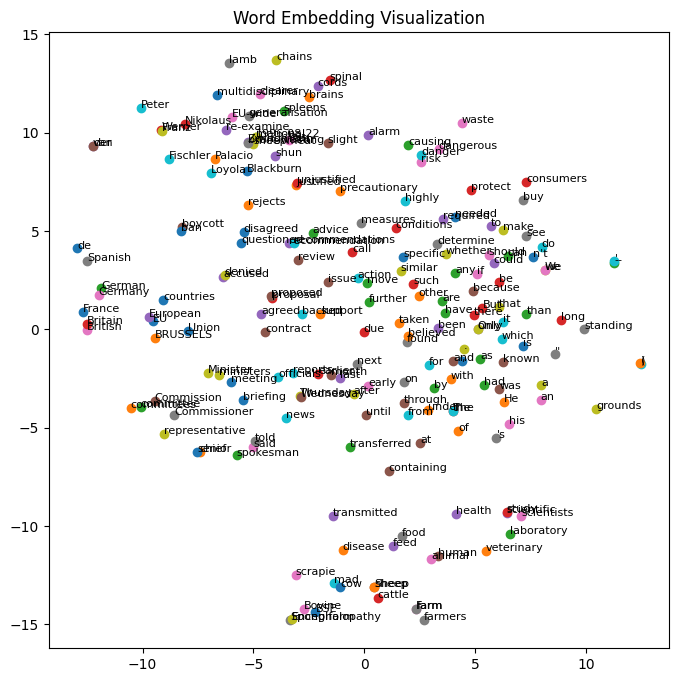

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

words = list(word2idx.keys())[:200]
vectors = [embedding_matrix[word2idx[w]] for w in words]

tsne = TSNE(n_components=2)
coords = tsne.fit_transform(np.array(vectors))

plt.figure(figsize=(8,8))
for i, word in enumerate(words):
    plt.scatter(coords[i,0], coords[i,1])
    plt.text(coords[i,0], coords[i,1], word, fontsize=8)

plt.title("Word Embedding Visualization")
plt.show()

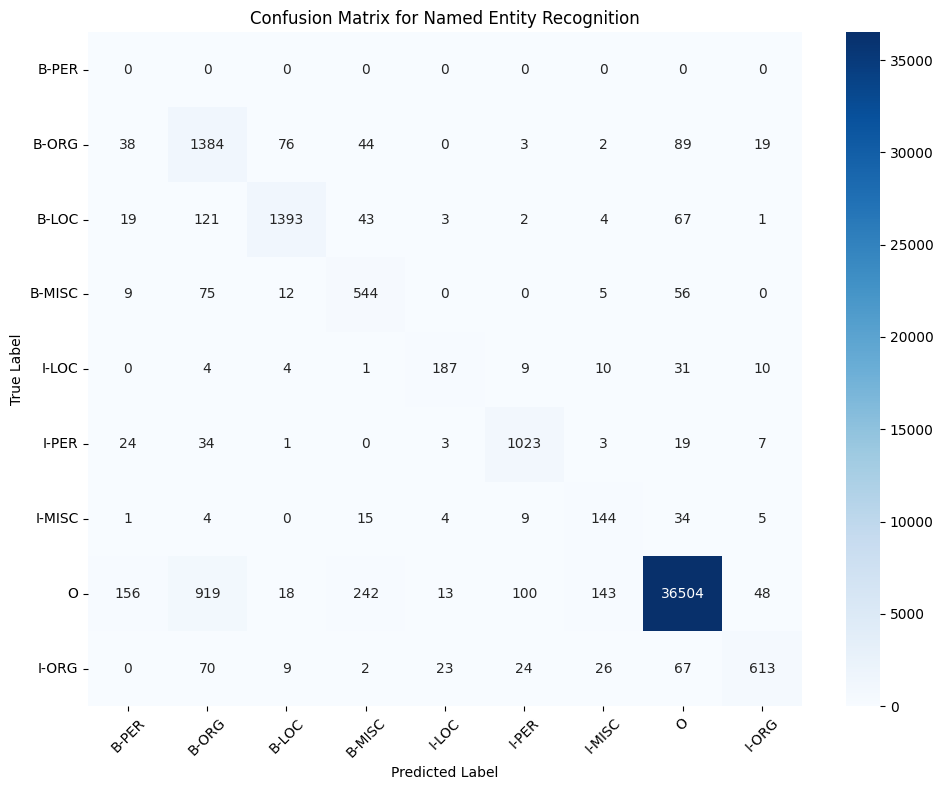

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

labels = list(tag2idx.keys())

cm = confusion_matrix(true_labels, pred_labels, labels=labels)
PAD_TAG = tag2idx["O"]   # or use explicit pad index if you created one

for i in range(len(y_test)):
    for j in range(len(y_test[i])):
        if X_test[i][j] != 0:   # check padding using input sequence
            true_labels.append(idx2tag[y_test[i][j]])
            pred_labels.append(idx2tag[y_pred[i][j]])

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Named Entity Recognition")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

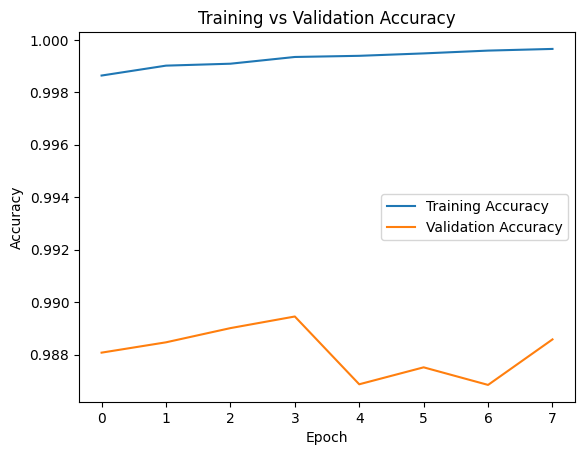

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

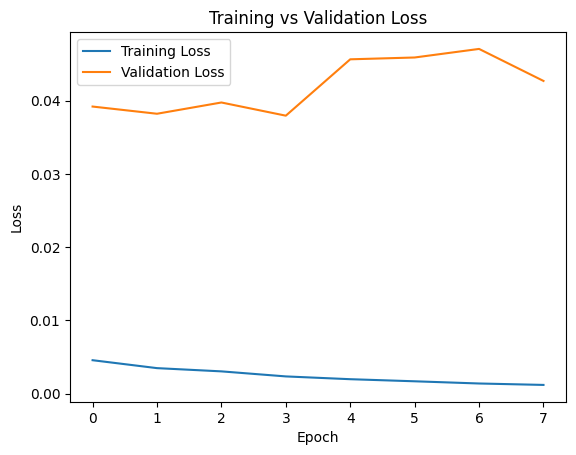

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()